# Task 2: Text Chunking, Embedding, and Vector Store Indexing

This notebook documents the complete process of:
1. Creating a stratified sample from the filtered complaints dataset
2. Implementing text chunking strategy
3. Generating embeddings using sentence-transformers
4. Building a FAISS vector store for semantic search

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

# Add src to path
sys.path.append('../src')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Stratified Sampling

We create a stratified sample of 12,000 complaints ensuring proportional representation across all product categories.

In [2]:
from sampling import create_stratified_sample

# Create stratified sample
sample_df = create_stratified_sample(
    input_file="../data/processed/filtered_complaints.csv",
    output_file="../data/processed/sample_complaints.csv",
    sample_size=12000,
    random_state=42
)

Loading data from ../data/processed/filtered_complaints.csv...

Original dataset shape: (66708, 19)

Product distribution in original dataset:
Product
Credit card        65272
Money transfers     1436
Name: count, dtype: int64

Product distribution (%):
Product
Credit card        97.847335
Money transfers     2.152665
Name: proportion, dtype: float64

Target samples per product:
  Credit card: 11742
  Money transfers: 258

Sample dataset shape: (12000, 19)

Product distribution in sample:
Product
Credit card        11742
Money transfers      258
Name: count, dtype: int64

Product distribution in sample (%):
Product
Credit card        97.85
Money transfers     2.15
Name: proportion, dtype: float64

Stratified sample saved to ../data/processed/sample_complaints.csv


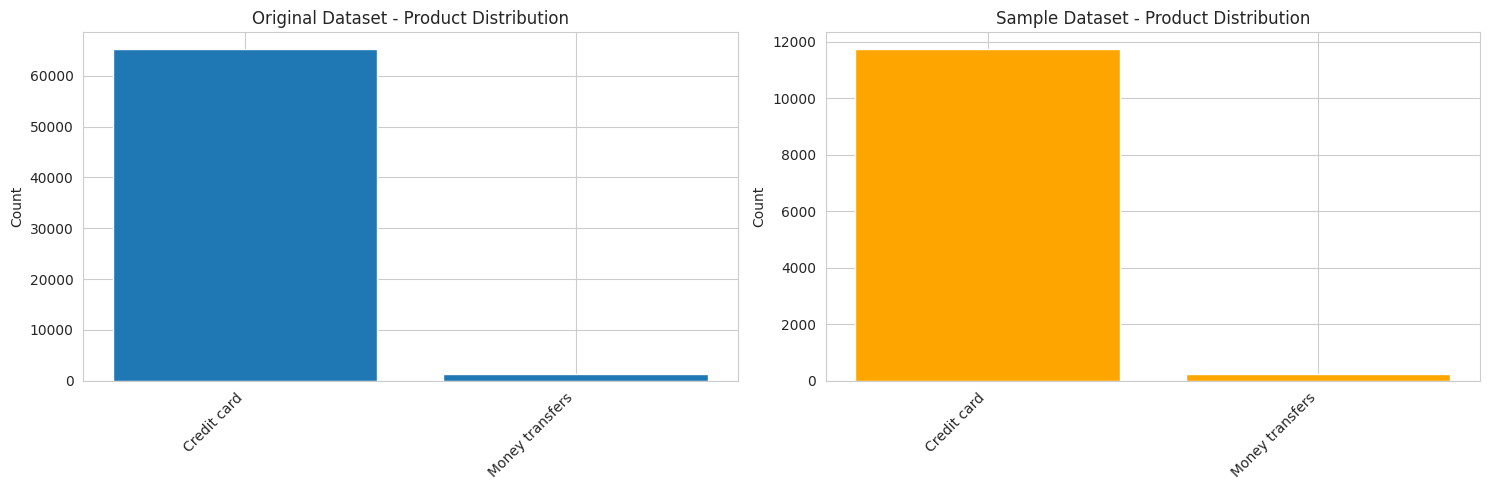


Proportional representation check:
Original proportions:
Product
Credit card        97.847335
Money transfers     2.152665
Name: proportion, dtype: float64

Sample proportions:
Product
Credit card        97.85
Money transfers     2.15
Name: proportion, dtype: float64


In [3]:
# Visualize product distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Original dataset
original_df = pd.read_csv("../data/processed/filtered_complaints.csv")
original_counts = original_df['Product'].value_counts()
axes[0].bar(range(len(original_counts)), original_counts.values)
axes[0].set_xticks(range(len(original_counts)))
axes[0].set_xticklabels(original_counts.index, rotation=45, ha='right')
axes[0].set_title('Original Dataset - Product Distribution')
axes[0].set_ylabel('Count')

# Sample dataset
sample_counts = sample_df['Product'].value_counts()
axes[1].bar(range(len(sample_counts)), sample_counts.values, color='orange')
axes[1].set_xticks(range(len(sample_counts)))
axes[1].set_xticklabels(sample_counts.index, rotation=45, ha='right')
axes[1].set_title('Sample Dataset - Product Distribution')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../report/images/sampling_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nProportional representation check:")
print("Original proportions:")
print(original_df['Product'].value_counts(normalize=True) * 100)
print("\nSample proportions:")
print(sample_df['Product'].value_counts(normalize=True) * 100)

## 2. Text Chunking

We use LangChain's RecursiveCharacterTextSplitter with:
- **Chunk size**: 500 characters (matches pre-built embeddings)
- **Chunk overlap**: 50 characters (10% overlap for context preservation)
- **Separators**: Prioritize paragraph and sentence boundaries

In [ ]:
from chunking import create_text_chunks, analyze_chunks, save_chunks

# Create text chunks
chunks_data = create_text_chunks(
    df=sample_df,
    chunk_size=500,
    chunk_overlap=50,
    text_column="Consumer complaint narrative"
)

# Analyze chunks
analyze_chunks(chunks_data)

# Save chunks
save_chunks(chunks_data, "../data/processed/sample_chunks.csv")

In [ ]:
# Visualize chunk statistics
chunk_lengths = [len(chunk['text']) for chunk in chunks_data]
chunks_per_complaint = {}
for chunk in chunks_data:
    cid = chunk['complaint_id']
    chunks_per_complaint[cid] = chunk['total_chunks']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Chunk length distribution
axes[0].hist(chunk_lengths, bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(np.mean(chunk_lengths), color='red', linestyle='--', label=f'Mean: {np.mean(chunk_lengths):.0f}')
axes[0].axvline(np.median(chunk_lengths), color='green', linestyle='--', label=f'Median: {np.median(chunk_lengths):.0f}')
axes[0].set_xlabel('Chunk Length (characters)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Chunk Lengths')
axes[0].legend()

# Chunks per complaint distribution
chunks_counts = list(chunks_per_complaint.values())
axes[1].hist(chunks_counts, bins=range(1, max(chunks_counts)+2), edgecolor='black', alpha=0.7, color='orange')
axes[1].axvline(np.mean(chunks_counts), color='red', linestyle='--', label=f'Mean: {np.mean(chunks_counts):.2f}')
axes[1].set_xlabel('Chunks per Complaint')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Chunks per Complaint')
axes[1].legend()

plt.tight_layout()
plt.savefig('../report/images/chunking_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Embedding Generation

We use the **sentence-transformers/all-MiniLM-L6-v2** model:
- **Embedding dimension**: 384
- **Model size**: ~80MB
- **Performance**: Fast inference, good quality for semantic search
- **Consistency**: Matches the pre-built embeddings for Tasks 3-4

In [ ]:
from embedding import generate_embeddings, analyze_embeddings, save_embeddings

# Generate embeddings
embeddings, chunks_df = generate_embeddings(
    chunks_file="../data/processed/sample_chunks.csv",
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    batch_size=32
)

# Analyze embeddings
analyze_embeddings(embeddings)

# Save embeddings
save_embeddings(embeddings, chunks_df, "../data/processed/sample_embeddings.npy")

In [ ]:
# Visualize embedding statistics
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Embedding value distribution
axes[0].hist(embeddings.flatten(), bins=100, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Embedding Value')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Embedding Values')
axes[0].set_yscale('log')

# Embedding norms
norms = np.linalg.norm(embeddings, axis=1)
axes[1].hist(norms, bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1].axvline(np.mean(norms), color='red', linestyle='--', label=f'Mean: {np.mean(norms):.4f}')
axes[1].set_xlabel('L2 Norm')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Embedding Norms')
axes[1].legend()

plt.tight_layout()
plt.savefig('../report/images/embedding_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. FAISS Vector Store

We build a FAISS vector store for efficient similarity search:
- **Index type**: Flat (exact search)
- **Similarity metric**: Cosine similarity (via Inner Product on normalized vectors)
- **Metadata**: Full complaint metadata stored with each chunk

In [ ]:
from vector_store_builder import build_vector_store, test_vector_store

# Build vector store
store = build_vector_store(
    embeddings_file="../data/processed/sample_embeddings.npy",
    metadata_file="../data/processed/sample_chunks.csv",
    output_dir="../vector_store/faiss_index",
    index_type="flat"
)

# Test vector store
test_vector_store(store)

## 5. Interactive Testing

Let's test the vector store with custom queries:

In [ ]:
from vector_store_builder import FAISSVectorStore

# Load the vector store
store = FAISSVectorStore.load("../vector_store/faiss_index")
store.load_model()

# Custom query
query = "I want to dispute fraudulent charges on my account"
results = store.query(query, k=5)

print(f"Query: '{query}'\n")
print("="*80)

for i, result in enumerate(results, 1):
    print(f"\nResult {i}:")
    print(f"  Similarity: {result['similarity']:.4f}")
    print(f"  Product: {result.get('product_category', 'N/A')}")
    print(f"  Issue: {result.get('issue', 'N/A')}")
    print(f"  Company: {result.get('company', 'N/A')}")
    print(f"  State: {result.get('state', 'N/A')}")
    print(f"  Text: {result.get('text', '')[:300]}...")
    print("-"*80)

In [ ]:
# Test with metadata filtering
query = "problems with online banking"
results = store.query(query, k=5, filter_metadata={'product_category': 'Checking or savings account'})

print(f"Query: '{query}'")
print(f"Filter: Product = 'Checking or savings account'\n")
print("="*80)

for i, result in enumerate(results, 1):
    print(f"\nResult {i}:")
    print(f"  Similarity: {result['similarity']:.4f}")
    print(f"  Product: {result.get('product_category', 'N/A')}")
    print(f"  Issue: {result.get('issue', 'N/A')}")
    print(f"  Text: {result.get('text', '')[:200]}...")
    print("-"*80)

## Summary

### Achievements:
1. ✅ Created stratified sample of 12,000 complaints with proportional product representation
2. ✅ Implemented text chunking with 500-character chunks and 50-character overlap
3. ✅ Generated 384-dimensional embeddings using all-MiniLM-L6-v2
4. ✅ Built FAISS vector store with metadata support
5. ✅ Tested semantic search with sample queries

### Key Decisions:
- **Sample size**: 12,000 (middle of 10k-15k range) for manageable processing
- **Chunk size**: 500 characters to match pre-built embeddings
- **Chunk overlap**: 50 characters (10%) to preserve context at boundaries
- **Embedding model**: all-MiniLM-L6-v2 for consistency with Tasks 3-4
- **Vector store**: FAISS Flat index for exact search on sample dataset

### Next Steps (Tasks 3-4):
- Use pre-built embeddings (complaint_embeddings.parquet) for full dataset
- Build RAG system with LangChain
- Implement query processing and response generation